In [101]:
import jax.numpy as jnp
from scipy.stats import norm, multivariate_normal, binom, poisson
from IPython.display import Markdown, display
from jax import random
import numpy as np

def to_latex_matrix(matrix):
    """Convert a JAX/numpy matrix to a LaTeX bmatrix string."""
    rows = []
    for row in matrix:
        rows.append(" & ".join(f"{val:.2f}" for val in row))
    return r"\begin{bmatrix}" + r" \\ ".join(rows) + r"\end{bmatrix}"

def to_latex_vector(vector):
    """Convert a JAX/numpy vector to a LaTeX bmatrix column vector."""
    rows = r" \\ ".join(f"{val:.2f}" for val in vector)
    return r"\begin{bmatrix}" + rows + r"\end{bmatrix}"

# Part 1

In [31]:
def softmax(a_, axis=1):
    max_val = jnp.max(a_, axis=axis)                # get maximum value along axis
    a = a_ - jnp.expand_dims(max_val, axis=axis)    # subtract max value for numerical stability
    exp_a = jnp.exp(a)                                
    return exp_a/jnp.sum(exp_a, axis=axis)[:, None]

def design_matrix(x):
    return jnp.column_stack((jnp.ones(len(x)), x))

def compute_entropy(pi):
    """ assumes pi is [N, K] where N is the number of prediction points and K is the number of classes """ 
    log_pi = jnp.where(pi > 0, jnp.log(pi), 0)  # equal to log(p) when p > 0 else 0
    H = -jnp.sum(pi*log_pi, 1)
    return H

def compute_confidence(pi):
    """ assumes pi is [N, K] where N is the number of prediction points and K is the number of classes """
    return jnp.max(pi, 1)

## Question 1.1

$$\prod^{N}_{n = 1} \text{Categorical}[\text{softmax}(\bf{W} \phi(x_{n}))]$$

where

$$p(\bf{W}) = \prod_{i = 1}^{I} \prod_{j = 1}^{J} \mathcal{N}(w_{ij} | 0, \alpha^{-1})$$

## Question 1.2 

In [18]:
W_MAP = jnp.array([[-0.5, -2.0],[3,0],[1,1]])

xstar = jnp.array([-1])
phi_star = design_matrix(xstar)

softmax(jnp.array([W_MAP @ phi_star[0]]))

Array([[0.17529039, 0.785597  , 0.03911257]], dtype=float32)

#### Answer: $y_{n} \sim \text{Categorical}[0.18, 0.79, 0.04]$

## Question 1.3

In [26]:
W1 = jnp.array([[-0.15, -1.92],[3.2,0.45],[1.37, 0.8]])
W2 = jnp.array([[-0.31, -2.03],[2.98,0.08],[1.03, 1.29]])
W3 = jnp.array([[-0.35, -1.98],[3.09,0.07],[1.3, 0.96]])

c1 =softmax(jnp.array([W1 @ phi_star[0]]))
c2 = softmax(jnp.array([W2 @ phi_star[0]]))
c3 = softmax(jnp.array([W3 @ phi_star[0]]))

c1*(1/3) + c2*(1/3) + c3*(1/3)

Array([[0.22295359, 0.72390676, 0.05313966]], dtype=float32)

## Question 1.4

In [34]:
pred_dist = jnp.array([[0,0.27,0.73]])
entropy = compute_entropy(pred_dist)
confidence = compute_confidence(pred_dist)

print(f"Entropy of posterior predictive distribution for x^*=-1 is {entropy}")
print(f"Confidence of posterior predictive distribution for x^*=-1 is {confidence}")

Entropy of posterior predictive distribution for x^*=-1 is [0.58325887]
Confidence of posterior predictive distribution for x^*=-1 is [0.73]


# Part 2

In [63]:
#Define training data
xtrain = jnp.array([-2,0,2])[:, None]

#Define training targets
ytrain = jnp.array([-2.01, 1.41, 0.23])[:, None]

#Define test data
x_star = jnp.array([-2,0,2])[:, None]

#Define design matrix 
def design_matrix(x):
    return jnp.column_stack((jnp.ones(len(x)), x))

kappa = jnp.sqrt(2)
lengthscale = 2
sigma = 1/2

kernel = lambda x, xs: kappa**2*jnp.exp(-0.5*(x-xs)**2/lengthscale**2)

def kernel_func(x,xs):
    return kernel(x.T,xs)

k = kernel_func(x_star, xtrain)
K = kernel_func(xtrain, xtrain)
Kstar = kernel_func(x_star, x_star)
c = Kstar + jnp.eye(len(x_star)) * sigma**2


## Question 2.1

$$\kappa = \sqrt{2}, \ell = 2$$

## Question 2.2

In [64]:
prior_mu = 0
prior_var = kernel_func(xtrain, xtrain)

display(Markdown(rf"The prior predictive distribution is $p(y_* \mid x_*) = \mathcal{{N}}(y_* \mid \mu_*, \sigma_*^2)$ where $\mu_* = {prior_mu}$ and $\sigma_*^2 = {to_latex_matrix(prior_var)}$"))

The prior predictive distribution is $p(y_* \mid x_*) = \mathcal{N}(y_* \mid \mu_*, \sigma_*^2)$ where $\mu_* = 0$ and $\sigma_*^2 = \begin{bmatrix}2.00 & 1.21 & 0.27 \\ 1.21 & 2.00 & 1.21 \\ 0.27 & 1.21 & 2.00\end{bmatrix}$

## Question 2.3

In [65]:
C = K + jnp.eye(len(xtrain)) * sigma**2
post_mu_f = jnp.dot(k.T,jnp.linalg.solve(C, ytrain))
post_var_f = Kstar - jnp.dot(k.T,jnp.linalg.solve(C, k))

display(Markdown(rf"The predictive posterior distribution is $p(y_* \mid x_*, \bf{{y}}) = \mathcal{{N}}(y_* \mid \mu_{{y^{{*}} | y}}, \sigma_{{y^{{*}} | y}}^2)$ where $\mu_* = {to_latex_matrix(post_mu_f)}$ and $\sigma_*^2 = {to_latex_matrix(post_var_f)}$"))

The predictive posterior distribution is $p(y_* \mid x_*, \bf{y}) = \mathcal{N}(y_* \mid \mu_{y^{*} | y}, \sigma_{y^{*} | y}^2)$ where $\mu_* = \begin{bmatrix}-1.53 \\ 0.89 \\ 0.43\end{bmatrix}$ and $\sigma_*^2 = \begin{bmatrix}0.21 & 0.03 & -0.01 \\ 0.03 & 0.19 & 0.03 \\ -0.01 & 0.03 & 0.21\end{bmatrix}$

# Part 3

## Question 3.1

We use the following equation to compute the maximum likelihood estimate for $\theta$

$$\hat{\theta}_{\text{MLE}} = (\Phi^{T} \Phi)^{-1} \Phi^{T} \bm{y}$$

where 

$$X = \Phi$$

In [35]:
X = jnp.array([[1,0.5],[-1,1]])
ytrain = jnp.array([1,0])
def w_MLE(phi):
    return jnp.linalg.solve(phi.T@phi, phi.T@ytrain).ravel()

w_MLE(phi=X)

Array([0.6666667, 0.6666667], dtype=float32)

## Question 3.2

In [45]:
theta = jnp.array([0,0])
m = jnp.array([1,1])
y = jnp.array([1,0])
sigma = 1
tau = 1
(1/2) * multivariate_normal.pdf(x = theta, mean = -m, cov = jnp.eye(2)) + (1/2) * multivariate_normal.pdf(x = theta, mean = m, cov = jnp.eye(2))

np.float64(0.05854983152431917)

## Question 3.3

$$\int{\mathcal{N}(y | X \theta, \sigma^{2} \bf{I})\left[\frac{1}{2} \mathcal{N}(\theta, -m, \tau^{2} \bf{I}) + \frac{1}{2} \mathcal{N}(\theta, m, \tau^{2} \bf{I})\right] d\theta}$$

$$ = \frac{1}{2} \int{\mathcal{N}(y | X \theta, \sigma^{2} \bf{I})\left[ \mathcal{N}(\theta, -m, \tau^{2} \bf{I})\right] d\theta} + \frac{1}{2} \int{\mathcal{N}(y | X \theta, \sigma^{2} \bf{I})\left[ \mathcal{N}(\theta, m, \tau^{2} \bf{I})\right] d\theta}$$

Using equation $3.38$ in Murphy1 we get:

$$\frac{1}{2} \mathcal{N}(y | -X\theta, \sigma \bf{I} + \tau^{2} X X^{T}) + \frac{1}{2} \mathcal{N}(y | X\theta, \sigma \bf{I} + \tau^{2} X X^{T}) $$

## Question 3.4

In [50]:
prior = (1/2) * multivariate_normal.pdf(x = theta, mean = -m, cov = jnp.eye(2)) + (1/2) * multivariate_normal.pdf(x = theta, mean = m, cov = jnp.eye(2))
likelihood = multivariate_normal.pdf(x = y, mean = X @ theta, cov = sigma**2 * jnp.eye(2))
marginal_likelihood = 0.5 * multivariate_normal.pdf(x = y, mean = X @ (-m), cov = sigma**2 * jnp.eye(2) + tau**2 *(X @ X.T)) + 0.5 * multivariate_normal.pdf(x = y, mean = X @ m, cov = sigma**2 * jnp.eye(2) + tau**2 *(X @ X.T))
print(prior, likelihood, marginal_likelihood)

0.05854983152431917 0.09653235263005393 0.03684121561813161


In [49]:
(likelihood * prior) / marginal_likelihood

np.float64(0.15341385696171722)

# Part 4

In [79]:
from packages.metropolis import metropolis

## Question 4.3

In [72]:
x = jnp.array([1,2,3])
y = jnp.array([10,4,1])
alpha = 8

In [83]:
def log_joint(w):
    w1 = w[0]
    w2 = w[1]
    
    likelihood = jnp.sum(poisson.logpmf(y, jnp.exp(3 + w1*x + w2*x**2)))
    prior = multivariate_normal.logpdf(x = jnp.array([w1,w2]), mean = jnp.zeros(2), cov = alpha**(-1) * jnp.eye(2))
    
    return likelihood + prior

In [84]:
mcmc = metropolis(log_target=log_joint, tau = 1, num_iter = 10**4, theta_init=jnp.array([0,0]), dis_prop=0.5, num_params=2)

Acceptance ratio: 0.04


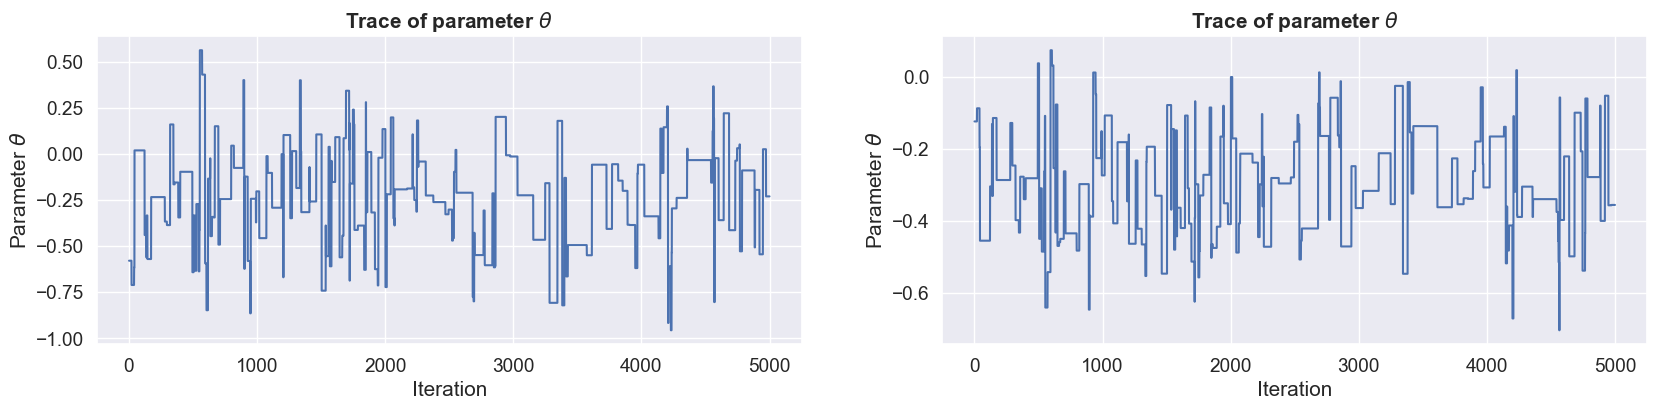

In [85]:
mcmc.plot_trace()

## Question 4.4

In [87]:
theta = mcmc.post_warmup_thetas

In [89]:
jnp.mean(theta[:,0] > 0)

Array(0.16436712, dtype=float32)

## Question 4.5

In [92]:
xstar = 1.5
mu = jnp.exp(3 + theta @ jnp.array([xstar, xstar**2]))

In [93]:
jnp.mean(mu > 7)

Array(0.6538692, dtype=float32)

## Question 4.6

In [98]:
key = random.key(1)
y_i = random.poisson(key = key, lam = mu)

In [105]:
jnp.percentile(y_i, jnp.array([5,95]))

Array([ 3., 13.], dtype=float32)

# Part 5

## Question 5.1

In [137]:
w = np.random.normal(size = 1000)
y = np.random.normal(loc = jnp.exp(w), size = 1000)

In [138]:
np.mean(y)

np.float64(1.7101864142276726)

## Question 5.2

In [140]:
w_map = 1.293404

In [141]:
norm.logpdf(x = w_map) + norm.logpdf(x = 5, loc = jnp.exp(w_map))

np.float64(-3.5921013752984914)